Polynomial Regression

Polynomial Regression is an extension of linear regression that models the relationship between the input and output as a polynomial equation, allowing it to capture non-linear patterns in the data.

Step 1: Define the Polynomial Regression Class

Here we implement a Polynomial Regression class to model the relationship between an input feature and a continuous target variable using a polynomial equation, allowing the model to capture non-linear patterns in the data.

- __init__(self, degree=2): Initializes the model with the specified polynomial degree and sets placeholders for coefficients, intercept, R2 score and polynomial transformer.
- fit(self, X, y): Transforms input X into polynomial features, computes coefficients using the normal equation, stores the intercept, makes predictions and calculates the R2 score.
- predict(self, X): Generates predictions for new input data.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures

class PolynomialRegression:
    def __init__(self, degree=2):
        self.degree = degree
        self.coefficients_ = None
        self.intercept_ = None
        self.r2score_ = None
        self.poly_features = None
        self.y_pred_ = None
        
    def fit(self, X, y):
        self.poly_features = PolynomialFeatures(
            degree=self.degree,
            include_bias=True
        )

        X_poly = self.poly_features.fit_transform(X)

        # Normal Equation
        self.coefficients_ = (
            np.linalg.inv(X_poly.T.dot(X_poly))
            .dot(X_poly.T)
            .dot(y)
        )

        self.intercept_ = self.coefficients_[0]

        # Predictions
        self.y_pred_ = X_poly.dot(self.coefficients_)

        # R²
        self.r2score_ = 1 - (
            np.sum((y - self.y_pred_)**2) /
            np.sum((y - np.mean(y))**2)
        )

    def predict(self, X):
        X_poly = self.poly_features.transform(X)
        return X_poly.dot(self.coefficients_)

Step 2: Train the Model and Visualize the Fit

- Here we generate sample data
- Train the polynomial regression model on it
- Visualize how well the model fits the data.
- The plot shows the original data points and the polynomial curve representing the model’s predictions

Polynomial LR Coefficients: [1.94067699 0.94285507 0.51753655]
R² Score: 0.95


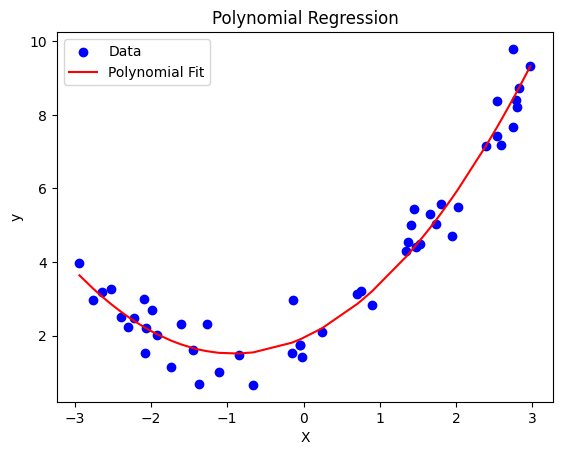

In [7]:
X_poly = np.random.rand(50,1)*6 - 3
y_poly = 0.5*X_poly**2 + X_poly + 2 + np.random.randn(50,1)*0.5
y_poly = y_poly.flatten()

# Modelo
pr = PolynomialRegression(degree=2)
pr.fit(X_poly, y_poly)

print(f"Polynomial LR Coefficients: {pr.coefficients_}")
print(f"R² Score: {pr.r2score_:.2f}")

# Ordenar para graficar correctamente
sorted_idx = np.argsort(X_poly[:,0])

plt.scatter(X_poly, y_poly, color='blue', label='Data')

plt.plot(
    X_poly[sorted_idx],
    pr.y_pred_[sorted_idx],
    color='red',
    label='Polynomial Fit'
)

plt.title("Polynomial Regression")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()